In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
data = pd.read_csv('/spam_ham_dataset.csv')

In [3]:
data.head()

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0


In [4]:
data.drop('Unnamed: 0', axis=1, inplace=True)

In [5]:
data.drop('label', axis=1, inplace=True)

In [6]:
data.head()

,text,label_num
0,Subject: enron methanol ; meter # : 988291\r\n...,0
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,"Subject: photoshop , windows , office . cheap ...",1
4,Subject: re : indian springs\r\nthis deal is t...,0


In [7]:
data['text'][0]

"Subject: enron methanol ; meter # : 988291\r\nthis is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary\r\nflow data provided by daren } .\r\nplease override pop ' s daily volume { presently zero } to reflect daily\r\nactivity you can obtain from gas control .\r\nthis change is needed asap for economics purposes ."

In [8]:
data.loc[0, 'text']


"Subject: enron methanol ; meter # : 988291\r\nthis is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary\r\nflow data provided by daren } .\r\nplease override pop ' s daily volume { presently zero } to reflect daily\r\nactivity you can obtain from gas control .\r\nthis change is needed asap for economics purposes ."

In [ ]:
#pd.set_option('display.max_colwidth', None)
#data.head()


In [12]:
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [13]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # Lowercase
    text = text.lower()

    # Remove non-alphabetic characters
    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords + lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    # Join back
    return " ".join(tokens)


In [14]:
data['clean_text'] = data['text'].apply(clean_text)
data.head()

,text,label_num,clean_text
0,Subject: enron methanol ; meter # : 988291\r\n...,0,subject enron methanol meter follow note gave ...
1,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,subject hpl nom january see attached file hpln...
2,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,subject neon retreat ho ho ho around wonderful...
3,"Subject: photoshop , windows , office . cheap ...",1,subject photoshop window office cheap main tre...
4,Subject: re : indian springs\r\nthis deal is t...,0,subject indian spring deal book teco pvr reven...


In [16]:
tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(data['clean_text']).toarray()
y = data['label_num']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [20]:
X_train.shape

(4136, 5000)

In [21]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [22]:
y_pred = model.predict(X_test)

In [23]:
y_pred

array([0, 1, 0, ..., 1, 0, 0])

In [24]:
y_test

,label_num
1566,0
1988,1
1235,0
2868,0
4903,0
...,...
1175,1
4476,0
4198,1
2689,0


In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9835748792270531
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       742
           1       0.97      0.98      0.97       293

    accuracy                           0.98      1035
   macro avg       0.98      0.98      0.98      1035
weighted avg       0.98      0.98      0.98      1035



In [30]:
confusion_matrix(y_test, y_pred)

array([[732,  10],
       [  7, 286]])

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import numpy as np
from sklearn.metrics import confusion_matrix, roc_curve, auc

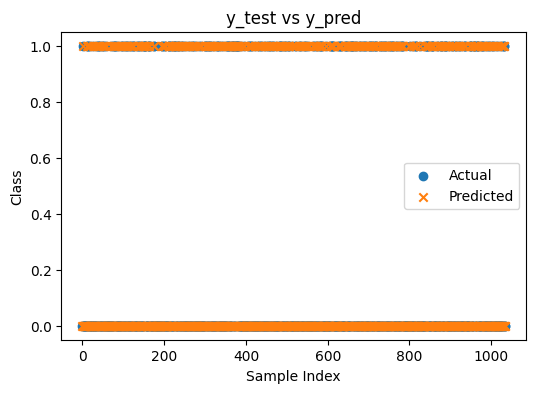

In [35]:
plt.figure(figsize=(6,4))
plt.scatter(range(len(y_test)), y_test, label="Actual", marker='o')
plt.scatter(range(len(y_pred)), y_pred, label="Predicted", marker='x')
plt.title("y_test vs y_pred")
plt.xlabel("Sample Index")
plt.ylabel("Class")
plt.legend()
plt.show()


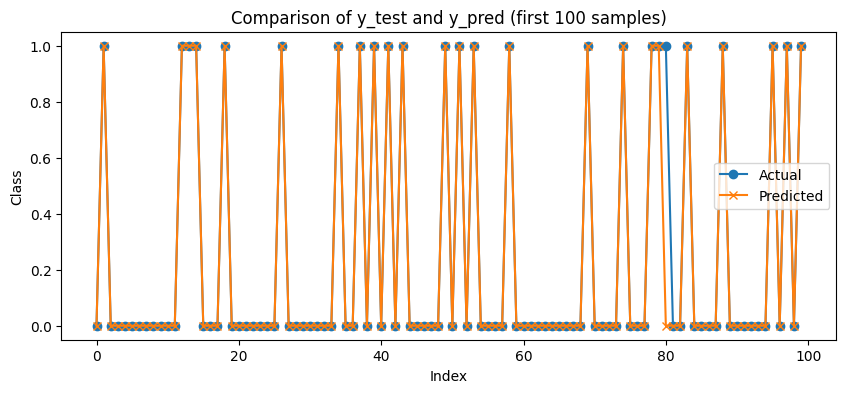

In [36]:
plt.figure(figsize=(10,4))
plt.plot(y_test.values[:100], label="Actual", marker='o')
plt.plot(y_pred[:100], label="Predicted", marker='x')
plt.title("Comparison of y_test and y_pred (first 100 samples)")
plt.xlabel("Index")
plt.ylabel("Class")
plt.legend()
plt.show()


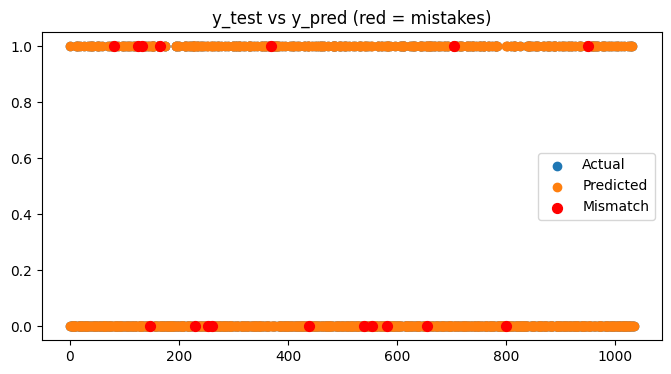

In [37]:
mismatch = y_test.values != y_pred

plt.figure(figsize=(8,4))
plt.scatter(range(len(y_test)), y_test, label="Actual")
plt.scatter(range(len(y_pred)), y_pred, label="Predicted")
plt.scatter(np.where(mismatch)[0], y_test[mismatch], color='red', label="Mismatch", s=50)
plt.title("y_test vs y_pred (red = mistakes)")
plt.legend()
plt.show()


In [38]:
import pickle

# Save TFIDF vectorizer
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

# Save model
with open("spam_model.pkl", "wb") as f:
    pickle.dump(model, f)


In [39]:
# Load vectorizer
with open("tfidf_vectorizer.pkl", "rb") as f:
    tfidf = pickle.load(f)

# Load model
with open("spam_model.pkl", "rb") as f:
    model = pickle.load(f)

In [40]:
def predict_email(text):
    # Preprocess (same cleaning steps)
    ct = clean_text(text)

    # Convert text to vector
    vector = tfidf.transform([ct])

    # Predict
    pred = model.predict(vector)[0]

    return "Spam" if pred == 1 else "Ham"

In [41]:
email = """Dear user, You have won $5000 cash reward. Click here to claim."""
print(predict_email(email))

Spam


In [42]:
email = """Hello sir, attached is the invoice for your approval."""

result = predict_email(email)
print("Prediction:", result)

Prediction: Ham
